# Notebook 2 — Tratamento de Outliers e Treinamento dos Modelos

**Entrada:** `database/train_processed.csv` e `database/anova_colunas_remover.json` (gerados pelo Notebook 1)

**Objetivo:**
1. Importar os dados já tratados
2. Remover as colunas indicadas pela ANOVA
3. Tratar outliers no conjunto de treino
4. Treinar e comparar os modelos regressores
5. Salvar modelos, scaler e metadados

**Saída:** artefatos em `models/` prontos para o Notebook 3

In [1]:
# Instalar dependências caso não estejam presentes
import subprocess, sys
pkgs = ["seaborn", "xgboost", "lightgbm"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Dependências OK")

Dependências OK


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style='whitegrid')
os.makedirs('models', exist_ok=True)
print('Imports concluídos.')

Imports concluídos.


## 2. Carregar dados do Notebook 1

In [3]:
df_train = pd.read_csv('database/train_processed.csv')

with open('database/anova_colunas_remover.json', 'r', encoding='utf-8') as f:
    colunas_remover = json.load(f)

print(f'Dados carregados: {df_train.shape}')
print(f'Colunas a remover (ANOVA + identificadores): {colunas_remover}')

Dados carregados: (8685, 27)
Colunas a remover (ANOVA + identificadores): ['ID', 'Faixa_Preco', 'Classificacao_Veiculo', 'Modelo', 'Data_ultima_lavagem', 'Adesivos_personalizados', 'Codigo_concessionaria', 'Portas', 'Numero', 'Radio', 'Historico', 'Dias']


## 3. Remover colunas indicadas pela ANOVA

In [4]:
df_model = df_train.drop(
    columns=[c for c in colunas_remover if c in df_train.columns]
).dropna(subset=['Preco'])

print(f'Shape após remoção de colunas: {df_model.shape}')
print(f'Colunas mantidas: {df_model.columns.tolist()}')

Shape após remoção de colunas: (8261, 19)
Colunas mantidas: ['Débitos', 'Fabricante', 'Ano', 'Categoria', 'Couro', 'Combustivel', 'Volume_motor', 'Km', 'Cilindros', 'Tipo_cambio', 'Tração', 'Rodas', 'Cor', 'Airbags', 'Preco', 'Numero_proprietarios', 'Radio_AM_FM', 'Historico_troca_oleo', 'Dias_desde_lavagem']


## 4. Tratamento de Outliers

Estratégia: remoção baseada em IQR para Km e Volume_motor; para Preço usamos o percentil 99 para não excluir veículos de luxo de forma agressiva.

In [5]:
n_antes = len(df_model)

# --- Preço: remover acima do percentil 99 ---
p99_preco = df_model['Preco'].quantile(0.99)
df_model  = df_model[df_model['Preco'] <= p99_preco]
print(f'Após remoção outliers de Preço (p99={p99_preco:,.0f}): {len(df_model)} registros')

# --- Km: IQR ---
if 'Km' in df_model.columns:
    Q1_km = df_model['Km'].quantile(0.25)
    Q3_km = df_model['Km'].quantile(0.75)
    IQR_km = Q3_km - Q1_km
    lim_sup_km = Q3_km + 3.0 * IQR_km   # fator 3 → menos agressivo
    df_model = df_model[(df_model['Km'].isna()) | (df_model['Km'] <= lim_sup_km)]
    print(f'Após remoção outliers de Km (sup={lim_sup_km:,.0f}): {len(df_model)} registros')

# --- Volume_motor: IQR ---
if 'Volume_motor' in df_model.columns:
    Q1_vm = df_model['Volume_motor'].quantile(0.25)
    Q3_vm = df_model['Volume_motor'].quantile(0.75)
    IQR_vm = Q3_vm - Q1_vm
    lim_sup_vm = Q3_vm + 3.0 * IQR_vm
    df_model = df_model[(df_model['Volume_motor'].isna()) | (df_model['Volume_motor'] <= lim_sup_vm)]
    print(f'Após remoção outliers de Volume_motor (sup={lim_sup_vm:.2f}): {len(df_model)} registros')

n_depois = len(df_model)
print(f'\nTotal removido por outliers: {n_antes - n_depois} ({(n_antes - n_depois)/n_antes*100:.1f}%)')

Após remoção outliers de Preço (p99=85,026): 8178 registros
Após remoção outliers de Km (sup=524,235): 8129 registros
Após remoção outliers de Volume_motor (sup=4.60): 7951 registros

Total removido por outliers: 310 (3.8%)


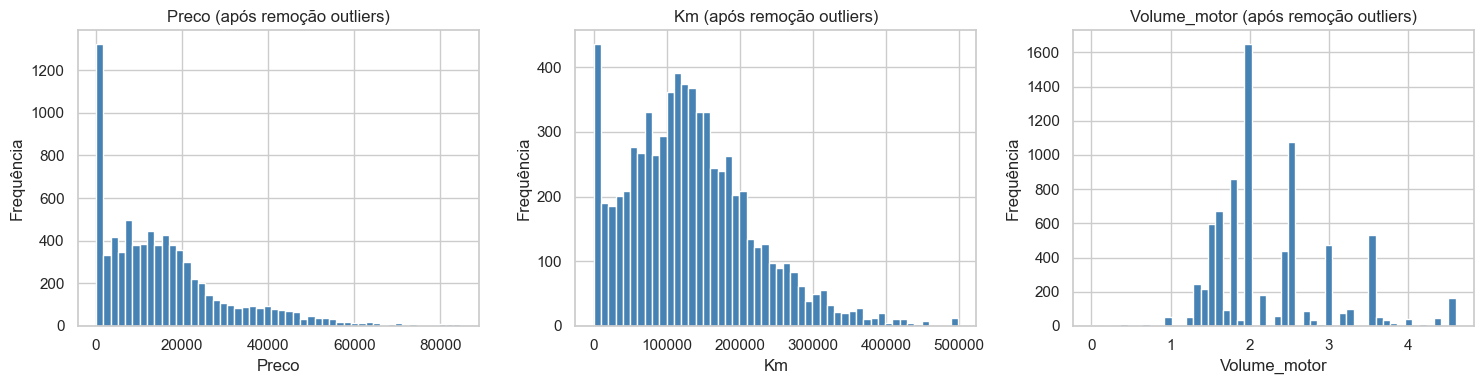

In [6]:
# Visualizar distribuições após remoção de outliers
colunas_viz = [c for c in ['Preco', 'Km', 'Volume_motor'] if c in df_model.columns]

fig, axes = plt.subplots(1, len(colunas_viz), figsize=(5 * len(colunas_viz), 4))
if len(colunas_viz) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas_viz):
    ax.hist(df_model[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} (após remoção outliers)')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('distribuicoes_pos_outlier.png', dpi=150)
plt.show()

## 5. Preparação das features (encoding + scaling + split)

In [7]:
# Converter tipos numéricos remanescentes
for col in ['Débitos', 'Km', 'Volume_motor']:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Encodar categóricas
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
df_enc   = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Separar X e y
X = df_enc.drop(columns=['Preco'])
y = df_enc['Preco']

# Converter bool → int e manter só numérico
X = X.astype({c: int for c in X.select_dtypes(include='bool').columns})
X = X.select_dtypes(include='number')
X = X.fillna(X.median())

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Colunas : {X.columns.tolist()}')

X shape : (7951, 102)
y shape : (7951,)
Colunas : ['Débitos', 'Ano', 'Volume_motor', 'Km', 'Cilindros', 'Rodas', 'Airbags', 'Numero_proprietarios', 'Historico_troca_oleo', 'Dias_desde_lavagem', 'Fabricante_ALFA ROMEO', 'Fabricante_AUDI', 'Fabricante_BMW', 'Fabricante_BUICK', 'Fabricante_CADILLAC', 'Fabricante_CHEVROLET', 'Fabricante_CHRYSLER', 'Fabricante_CITROEN', 'Fabricante_DAEWOO', 'Fabricante_DAIHATSU', 'Fabricante_DODGE', 'Fabricante_FIAT', 'Fabricante_FORD', 'Fabricante_GAZ', 'Fabricante_GMC', 'Fabricante_HAVAL', 'Fabricante_HONDA', 'Fabricante_HUMMER', 'Fabricante_HYUNDAI', 'Fabricante_INFINITI', 'Fabricante_ISUZU', 'Fabricante_JAGUAR', 'Fabricante_JEEP', 'Fabricante_KIA', 'Fabricante_LANCIA', 'Fabricante_LAND ROVER', 'Fabricante_LEXUS', 'Fabricante_LINCOLN', 'Fabricante_MASERATI', 'Fabricante_MAZDA', 'Fabricante_MERCEDES-BENZ', 'Fabricante_MERCURY', 'Fabricante_MINI', 'Fabricante_MITSUBISHI', 'Fabricante_MOSKVICH', 'Fabricante_NISSAN', 'Fabricante_OPEL', 'Fabricante_PEUGEOT', 

C:\Users\Lucas\AppData\Local\Temp\ipykernel_8812\3280630954.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


In [8]:
# Escalar
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Split treino / validação
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Treino   : {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')

Treino   : 6360 amostras
Validação: 1591 amostras


## 6. Treinamento dos modelos com GridSearchCV

In [9]:
modelos_params = {
    'Ridge': (
        Ridge(),
        {'alpha': [0.01, 0.1, 1, 10, 100]}
    ),
    'Random Forest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': [50, 100, 200],
         'max_depth'   : [5, 10, None]}
    ),
    'Gradient Boosting': (
        GradientBoostingRegressor(random_state=42),
        {'n_estimators' : [100, 200],
         'learning_rate': [0.05, 0.1],
         'max_depth'    : [3, 5]}
    ),
    'XGBoost': (
        XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
        {'n_estimators' : [100, 200],
         'learning_rate': [0.05, 0.1],
         'max_depth'    : [3, 5, 7],
         'subsample'    : [0.8, 1.0]}
    ),
    'LightGBM': (
        LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        {'n_estimators' : [200, 500, 1000],
         'learning_rate': [0.01, 0.05, 0.1],
         'max_depth'    : [5, 7, 10],
         'num_leaves'   : [31, 63, 127],
         'subsample'    : [0.8, 1.0]}
    ),
}

grid_searches = {}

for nome, (modelo, params) in modelos_params.items():
    print(f'⏳ Treinando {nome}...')
    inicio = time.time()
    gs = GridSearchCV(modelo, params, cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    grid_searches[nome] = gs
    tempo = (time.time() - inicio) / 60
    print(f'   Melhor config : {gs.best_params_}')
    print(f'   R² CV         : {gs.best_score_:.4f} | Tempo: {tempo:.1f} min\n')

print('✅ Todos os modelos treinados!')

⏳ Treinando Ridge...
   Melhor config : {'alpha': 100}
   R² CV         : 0.3563 | Tempo: 0.1 min

⏳ Treinando Random Forest...
   Melhor config : {'max_depth': None, 'n_estimators': 200}
   R² CV         : 0.6921 | Tempo: 0.2 min

⏳ Treinando Gradient Boosting...
   Melhor config : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
   R² CV         : 0.6938 | Tempo: 0.2 min

⏳ Treinando XGBoost...
   Melhor config : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
   R² CV         : 0.7062 | Tempo: 0.1 min

⏳ Treinando LightGBM...
   Melhor config : {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 1000, 'num_leaves': 31, 'subsample': 0.8}
   R² CV         : 0.6931 | Tempo: 5.6 min

✅ Todos os modelos treinados!


## 7. Ensemble (Voting Regressor)

In [10]:
ensemble = VotingRegressor(estimators=[
    ('xgb' , grid_searches['XGBoost'].best_estimator_),
    ('lgbm', grid_searches['LightGBM'].best_estimator_),
    ('rf'  , grid_searches['Random Forest'].best_estimator_),
], weights=[3, 2, 1])

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_val)

print('── ENSEMBLE ──')
print(f'R²  : {r2_score(y_val, y_pred_ens):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_ens)):,.0f}')
print(f'MAE : {mean_absolute_error(y_val, y_pred_ens):,.0f}')

── ENSEMBLE ──
R²  : 0.7100
RMSE: 8,043
MAE : 5,073


## 8. Avaliação comparativa dos modelos

In [11]:
# Baseline
y_pred_base = np.full(len(y_val), y_train.mean())

resultados = [{
    'Modelo': 'Baseline',
    'R²'    : r2_score(y_val, y_pred_base),
    'RMSE'  : np.sqrt(mean_squared_error(y_val, y_pred_base)),
    'MAE'   : mean_absolute_error(y_val, y_pred_base),
    'y_pred': y_pred_base,
}]

for nome, gs in grid_searches.items():
    y_pred = gs.best_estimator_.predict(X_val)
    resultados.append({
        'Modelo': nome,
        'R²'    : r2_score(y_val, y_pred),
        'RMSE'  : np.sqrt(mean_squared_error(y_val, y_pred)),
        'MAE'   : mean_absolute_error(y_val, y_pred),
        'y_pred': y_pred,
    })

resultados.append({
    'Modelo': 'Ensemble',
    'R²'    : r2_score(y_val, y_pred_ens),
    'RMSE'  : np.sqrt(mean_squared_error(y_val, y_pred_ens)),
    'MAE'   : mean_absolute_error(y_val, y_pred_ens),
    'y_pred': y_pred_ens,
})

df_res = pd.DataFrame(resultados).drop(columns=['y_pred'])
print('\n── RESULTADOS ──')
print(df_res.to_string(index=False))


── RESULTADOS ──
           Modelo        R²         RMSE          MAE
         Baseline -0.000730 14941.614518 11327.215076
            Ridge  0.383837 11724.299604  8628.328606
    Random Forest  0.686111  8368.107955  5177.105321
Gradient Boosting  0.696802  8224.364670  5317.119702
          XGBoost  0.706348  8093.851559  5118.600179
         LightGBM  0.702071  8152.581148  5243.056336
         Ensemble  0.710048  8042.697476  5072.897345


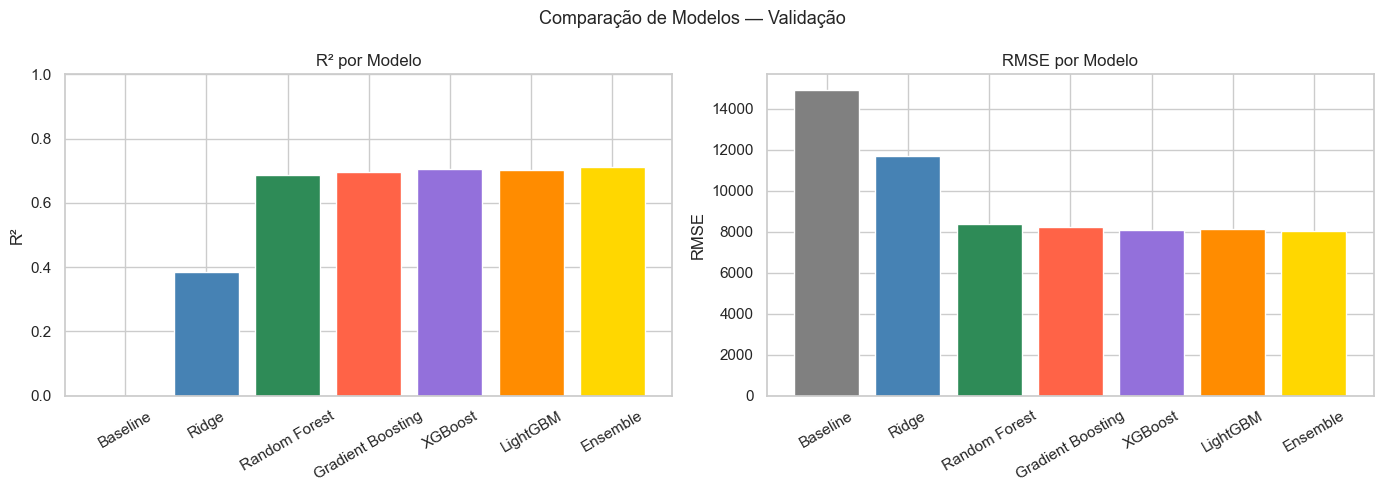

In [12]:
cores = ['gray', 'steelblue', 'seagreen', 'tomato', 'mediumpurple', 'darkorange', 'gold']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_res['Modelo'], df_res['R²'], color=cores[:len(df_res)], edgecolor='white')
axes[0].set_title('R² por Modelo')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df_res['Modelo'], df_res['RMSE'], color=cores[:len(df_res)], edgecolor='white')
axes[1].set_title('RMSE por Modelo')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Comparação de Modelos — Validação', fontsize=13)
plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150)
plt.show()

🏆 Melhor modelo na validação: Ensemble  R²=0.7100


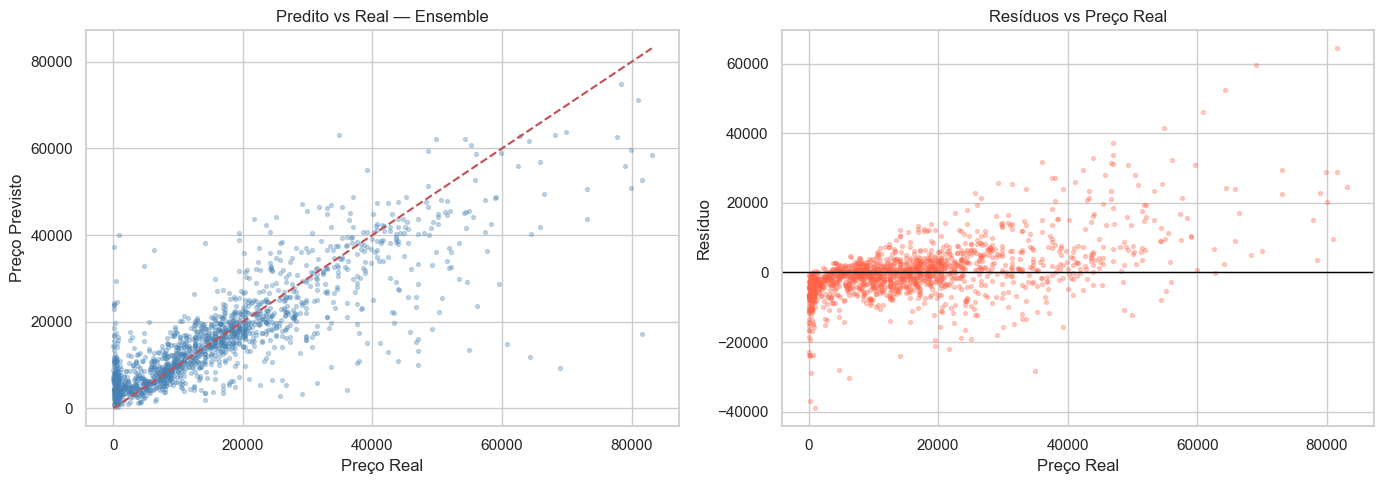

In [13]:
# Gráfico predito vs real — melhor modelo
melhor = max(resultados[1:], key=lambda x: x['R²'])
print(f'🏆 Melhor modelo na validação: {melhor["Modelo"]}  R²={melhor["R²"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_val, melhor['y_pred'], alpha=0.3, s=8, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[0].set_xlabel('Preço Real')
axes[0].set_ylabel('Preço Previsto')
axes[0].set_title(f'Predito vs Real — {melhor["Modelo"]}')

residuos = y_val.values - melhor['y_pred']
axes[1].scatter(y_val, residuos, alpha=0.3, s=8, color='tomato')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Preço Real')
axes[1].set_ylabel('Resíduo')
axes[1].set_title('Resíduos vs Preço Real')

plt.tight_layout()
plt.savefig('predito_vs_real.png', dpi=150)
plt.show()

## 9. Diagnóstico — resíduos por faixa de preço

In [14]:
# Usar o melhor modelo para diagnóstico
if melhor['Modelo'] in grid_searches:
    y_diag = grid_searches[melhor['Modelo']].best_estimator_.predict(X_val)
else:
    y_diag = melhor['y_pred']

df_diag = pd.DataFrame({
    'Preco_Real': y_val.values,
    'Residuo'   : y_val.values - y_diag,
    'Faixa'     : pd.cut(y_val, bins=5),
})

print('Erro médio (resíduo) por faixa de preço:')
print(df_diag.groupby('Faixa', observed=True)['Residuo']
      .agg(['mean', 'std', 'count']).round(0))

Erro médio (resíduo) por faixa de preço:
                       mean      std  count
Faixa                                      
(-80.104, 16623.8]  -2575.0   4915.0    939
(16623.8, 33244.6]   1341.0   6719.0    442
(33244.6, 49865.4]   6291.0  10955.0    150
(49865.4, 66486.2]  14340.0  12776.0     46
(66486.2, 83107.0]  24361.0  18372.0     14


## 10. Salvar modelos, scaler e metadados

In [15]:
# Scaler
joblib.dump(scaler, 'models/scaler.pkl')

# Modelos individuais
for nome, gs in grid_searches.items():
    nome_arquivo = nome.lower().replace(' ', '_')
    joblib.dump(gs.best_estimator_, f'models/modelo_{nome_arquivo}.pkl')

# Ensemble
joblib.dump(ensemble, 'models/modelo_ensemble.pkl')

# Colunas do treino (para alinhar o teste)
with open('models/colunas_treino.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

# Threshold de preço (p99 do treino — útil para identificar outliers no teste)
meta = {
    'p99_preco'     : float(p99_preco),
    'melhor_modelo' : melhor['Modelo'],
    'r2_validacao'  : round(melhor['R²'], 4),
    'rmse_validacao': round(melhor['RMSE'], 2),
    'mae_validacao' : round(melhor['MAE'], 2),
}
with open('models/metadados_treino.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ Artefatos salvos em models/:')
for arq in sorted(os.listdir('models')):
    print(f'   {arq}')

✅ Artefatos salvos em models/:
   best_regression_model.pkl
   colunas_treino.json
   metadados_treino.json
   modelo_ensemble.pkl
   modelo_gradient_boosting.pkl
   modelo_lightgbm.pkl
   modelo_random_forest.pkl
   modelo_ridge.pkl
   modelo_xgboost.pkl
   scaler.pkl


## Resumo

| Etapa | Detalhe |
|-------|---------|
| Dados de entrada | `train_processed.csv` do Notebook 1 |
| Colunas removidas | conforme `anova_colunas_remover.json` |
| Outliers removidos | Preço > p99, Km > Q3+3·IQR, Volume_motor > Q3+3·IQR |
| Modelos treinados | Ridge, Random Forest, Gradient Boosting, XGBoost, LightGBM, Ensemble |
| Saída para Notebook 3 | `models/` com pkl + json |